# GRC Risk Register & Controls Tracker — SQL Analysis

Exploratory analysis of the synthetic risk register, run directly against the
SQLite database with SQL queries (via `pandas.read_sql_query`), matching the
style of the companion [OpenAI Abuse Investigation Portfolio](https://github.com/jvandenhouten/openai-abuse-investigator-portfolio)
project.

**Note:** all data here is synthetic (see `README.md` / the app's Methodology
tab). This notebook demonstrates the SQL and analytical approach, not a real
organization's risk posture.


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

DB_PATH = Path("..") / "data" / "grc_register.db"
conn = sqlite3.connect(DB_PATH)


## 1. Risk register overview

In [2]:
df = pd.read_sql_query("""
    SELECT risk_code, title, risk_category, status, inherent_risk_score
    FROM risks
    ORDER BY inherent_risk_score DESC
""", conn)
print(f"{len(df)} risks in register")
df.head(10)


45 risks in register


,risk_code,title,risk_category,status,inherent_risk_score
0,RISK-0005,Lack of multi-factor authentication enforcement for privileged accounts,Cybersecurity,Monitoring,20
1,RISK-0012,Shadow IT: unsanctioned cloud applications used by business units,Cybersecurity,Open,20
2,RISK-0019,Inadequate visitor management and escort procedures at HQ,Physical Security,Open,20
3,RISK-0043,Inadequate emergency evacuation planning at Riyadh Regional Office,Safety / EHS,Monitoring,20
4,RISK-0010,Third-party vendor remote access without adequate network segmentation,Cybersecurity,Monitoring,16
5,RISK-0011,Inadequate endpoint detection and response coverage on field laptops,Cybersecurity,Open,16
6,RISK-0028,Fleet maintenance backlog increasing breakdown and downtime risk,Operational,Open,16
7,RISK-0039,Insufficient documentation supporting OSHA recordkeeping requirements,Compliance / Regulatory,Open,16
8,RISK-0042,Driver fatigue and hours-of-service risk on long-haul routes,Safety / EHS,Open,16
9,RISK-0044,Heat-related illness risk for outdoor field crews during Texas summer operat...,Safety / EHS,Monitoring,16


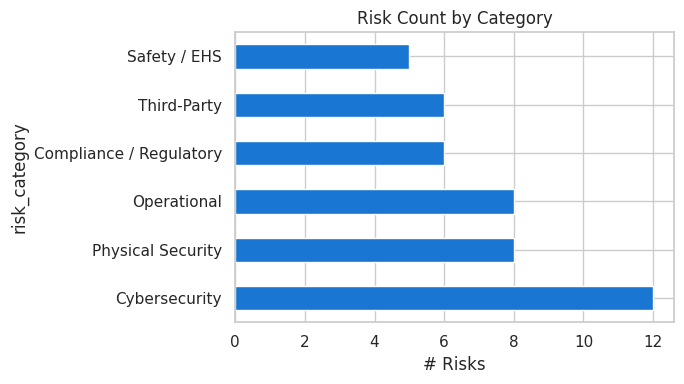

In [3]:
df["risk_category"].value_counts().plot(kind="barh", figsize=(7, 4), color="#1976d2")
plt.title("Risk Count by Category")
plt.xlabel("# Risks")
plt.tight_layout()
plt.show()


## 2. Inherent vs. residual risk

The residual score reflects the *analytical judgment* layer described in the
Methodology tab: inherent risk adjusted for the observed maturity of mapped
controls. We join `risks` to `residual_risk_assessments` to compare the two.


In [4]:
residual = pd.read_sql_query("""
    SELECT r.risk_code, r.title, r.risk_category, r.status,
           r.inherent_risk_score, rr.residual_risk_score, rr.rationale
    FROM risks r
    JOIN residual_risk_assessments rr ON rr.risk_id = r.risk_id
    ORDER BY r.inherent_risk_score - rr.residual_risk_score DESC
""", conn)
residual["risk_reduction"] = residual["inherent_risk_score"] - residual["residual_risk_score"]
residual.head(10)


,risk_code,title,risk_category,status,inherent_risk_score,residual_risk_score,rationale,risk_reduction
0,RISK-0042,Driver fatigue and hours-of-service risk on long-haul routes,Safety / EHS,Open,16,6,Inherent score 16 (L4 x I4) adjusted for control coverage: 1 mapped control(...,10
1,RISK-0005,Lack of multi-factor authentication enforcement for privileged accounts,Cybersecurity,Monitoring,20,12,Inherent score 20 (L4 x I5) adjusted for control coverage: 1 mapped control(...,8
2,RISK-0019,Inadequate visitor management and escort procedures at HQ,Physical Security,Open,20,12,Inherent score 20 (L4 x I5) adjusted for control coverage: 1 mapped control(...,8
3,RISK-0004,Weak / reused administrative credentials on core network infrastructure,Cybersecurity,Open,15,8,Inherent score 15 (L3 x I5) adjusted for control coverage: 2 mapped control(...,7
4,RISK-0007,Insufficient logging and monitoring delaying intrusion detection,Cybersecurity,Monitoring,15,8,Inherent score 15 (L3 x I5) adjusted for control coverage: 2 mapped control(...,7
5,RISK-0015,Tailgating / unauthorized facility access at Austin HQ,Physical Security,Open,15,8,Inherent score 15 (L3 x I5) adjusted for control coverage: 1 mapped control(...,7
6,RISK-0028,Fleet maintenance backlog increasing breakdown and downtime risk,Operational,Open,16,9,Inherent score 16 (L4 x I4) adjusted for control coverage: 1 mapped control(...,7
7,RISK-0041,Warehouse forklift operation safety gaps at San Marcos DC,Safety / EHS,Closed,15,8,Inherent score 15 (L3 x I5) adjusted for control coverage: 1 mapped control(...,7
8,RISK-0044,Heat-related illness risk for outdoor field crews during Texas summer operat...,Safety / EHS,Monitoring,16,9,Inherent score 16 (L4 x I4) adjusted for control coverage: 1 mapped control(...,7
9,RISK-0031,MENA security escort provider vetting gaps,Third-Party,Monitoring,12,6,Inherent score 12 (L3 x I4) adjusted for control coverage: 1 mapped control(...,6


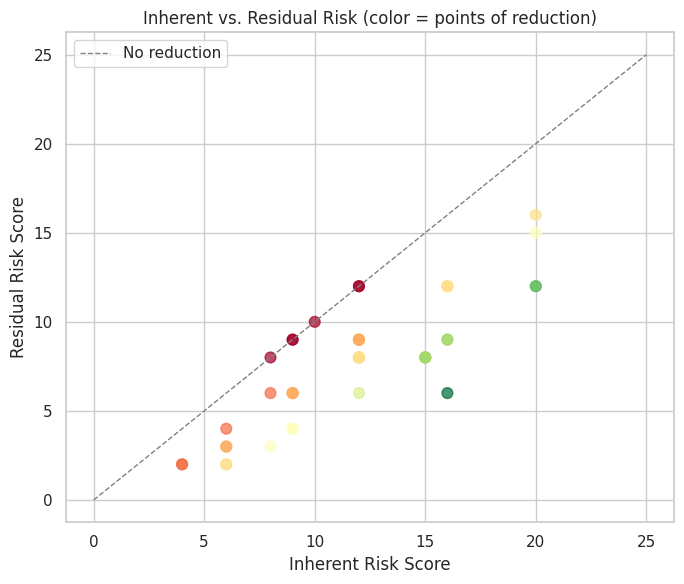

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(residual["inherent_risk_score"], residual["residual_risk_score"],
           alpha=0.7, s=60, c=residual["risk_reduction"], cmap="RdYlGn")
ax.plot([0, 25], [0, 25], linestyle="--", color="gray", linewidth=1, label="No reduction")
ax.set_xlabel("Inherent Risk Score")
ax.set_ylabel("Residual Risk Score")
ax.set_title("Inherent vs. Residual Risk (color = points of reduction)")
ax.legend()
plt.tight_layout()
plt.show()


**Reading this chart:** every point below the diagonal line represents a
risk where mapped controls measurably reduced exposure. Points close to the
diagonal are risks where controls exist on paper but are not yet mature enough
to meaningfully change the residual score — a useful prioritization signal for
where control investment would have the most impact.


## 3. Top residual risks (where to focus first)

In [6]:
top_risks = residual.sort_values("residual_risk_score", ascending=False).head(10)
top_risks[["risk_code", "title", "risk_category", "inherent_risk_score", "residual_risk_score"]]


,risk_code,title,risk_category,inherent_risk_score,residual_risk_score
19,RISK-0012,Shadow IT: unsanctioned cloud applications used by business units,Cybersecurity,20,16
14,RISK-0043,Inadequate emergency evacuation planning at Riyadh Regional Office,Safety / EHS,20,15
17,RISK-0010,Third-party vendor remote access without adequate network segmentation,Cybersecurity,16,12
2,RISK-0019,Inadequate visitor management and escort procedures at HQ,Physical Security,20,12
1,RISK-0005,Lack of multi-factor authentication enforcement for privileged accounts,Cybersecurity,20,12
18,RISK-0011,Inadequate endpoint detection and response coverage on field laptops,Cybersecurity,16,12
42,RISK-0023,Key-person dependency risk in MENA regional leadership,Operational,12,12
41,RISK-0021,Single point of failure in fleet telematics platform vendor,Operational,12,12
24,RISK-0039,Insufficient documentation supporting OSHA recordkeeping requirements,Compliance / Regulatory,16,12
39,RISK-0018,Lack of standardized executive protection protocol for MENA travel,Physical Security,10,10


## 4. Control maturity by NIST CSF 2.0 function

In [7]:
maturity_map = {
    "Not Implemented": 0, "Planned": 1, "Partially Implemented": 2,
    "Largely Implemented": 3, "Fully Implemented": 4,
}

controls = pd.read_sql_query("""
    SELECT c.control_code, c.name, c.implementation_status, c.category_id,
           cat.name AS category_name, f.function_id, f.name AS function_name
    FROM controls c
    JOIN csf_categories cat ON cat.category_id = c.category_id
    JOIN csf_functions f ON f.function_id = cat.function_id
""", conn)
controls["maturity"] = controls["implementation_status"].map(maturity_map)

fn_order = ["GV", "ID", "PR", "DE", "RS", "RC"]
fn_maturity = controls.groupby("function_id")["maturity"].mean().reindex(fn_order)
fn_maturity


function_id
GV    2.750000
ID    2.800000
PR    2.058824
DE    3.666667
RS    2.400000
RC    2.000000
Name: maturity, dtype: float64

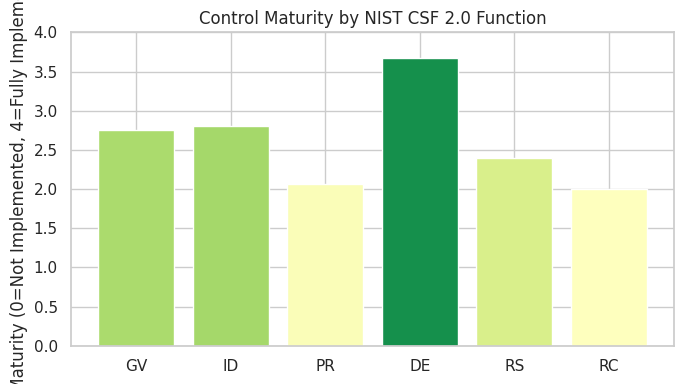

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.cm.RdYlGn(fn_maturity / 4)
ax.bar(fn_maturity.index, fn_maturity.values, color=colors)
ax.set_ylim(0, 4)
ax.set_ylabel("Avg. Maturity (0=Not Implemented, 4=Fully Implemented)")
ax.set_title("Control Maturity by NIST CSF 2.0 Function")
plt.tight_layout()
plt.show()


## 5. Category-level control maturity (lowest first)

Categories with the lowest average maturity relative to the number of risks
mapped into them are reasonable candidates for the next control-investment
cycle.


In [9]:
cat_maturity = controls.groupby(["function_id", "category_id", "category_name"])["maturity"].mean()
cat_maturity = cat_maturity.reset_index().sort_values("maturity")
cat_maturity.head(10)


,function_id,category_id,category_name,maturity
17,RC,RC.IM,Improvements,0.000000
20,RS,RS.CO,Incident Response Reporting and Communication,1.000000
15,PR,PR.PS,Platform Security,1.666667
6,GV,GV.RR,"Roles, Responsibilities, and Authorities",2.000000
13,PR,PR.DS,Data Security,2.000000
14,PR,PR.IR,Technology Infrastructure Resilience,2.000000
10,ID,ID.RA,Risk Assessment,2.000000
12,PR,PR.AT,Awareness and Training,2.000000
19,RS,RS.AN,Incident Analysis,2.000000
11,PR,PR.AA,"Identity Management, Authentication, and Access Control",2.333333


## 6. Remediation backlog analysis

In [10]:
remediation = pd.read_sql_query("""
    SELECT ra.action_code, ra.description, ra.priority, ra.status, ra.target_date,
           r.risk_code, r.title, r.risk_category
    FROM remediation_actions ra
    LEFT JOIN risks r ON r.risk_id = ra.risk_id
""", conn)

status_by_priority = pd.crosstab(remediation["priority"], remediation["status"])
status_by_priority = status_by_priority.reindex(["Critical", "High", "Medium", "Low"])
status_by_priority


status,Completed,In Progress,Not Started,Overdue
priority,,,,
Critical,2.0,0.0,0.0,2.0
High,2.0,11.0,8.0,3.0
Medium,2.0,3.0,1.0,1.0
Low,NaN,NaN,NaN,NaN


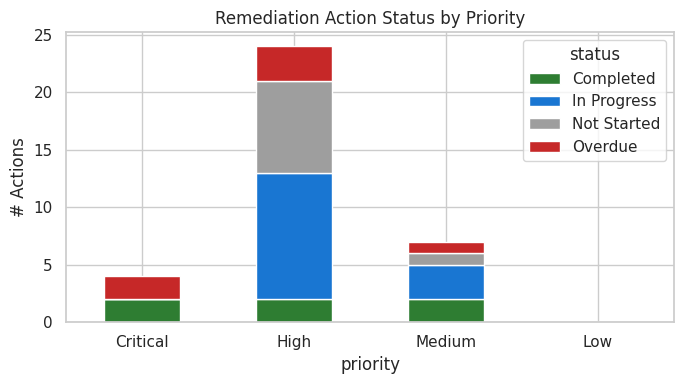

In [11]:
status_by_priority.plot(kind="bar", stacked=True, figsize=(7, 4),
                          color={"Not Started": "#9e9e9e", "In Progress": "#1976d2",
                                 "Completed": "#2e7d32", "Overdue": "#c62828"})
plt.title("Remediation Action Status by Priority")
plt.ylabel("# Actions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [12]:
overdue = remediation[remediation["status"] == "Overdue"].sort_values("priority")
print(f"{len(overdue)} overdue remediation action(s)")
overdue[["action_code", "description", "priority", "risk_code", "title", "target_date"]]


6 overdue remediation action(s)


,action_code,description,priority,risk_code,title,target_date
17,REM-0018,Implement physical security enhancement: formalizing and documenting the con...,Critical,RISK-0019,Inadequate visitor management and escort procedures at HQ,2026-11-11
32,REM-0033,Implement safety corrective action: expanding monitoring coverage to close t...,Critical,RISK-0043,Inadequate emergency evacuation planning at Riyadh Regional Office,2027-01-29
0,REM-0001,Remediate identified gap through formalizing and documenting the control pro...,High,RISK-0001,Ransomware compromise of corporate file shares and backups,2026-09-08
21,REM-0022,Address operational gap via completing overdue control testing and remediati...,High,RISK-0022,Inadequate business continuity plan for San Marcos DC outage,2026-11-11
33,REM-0034,Implement safety corrective action: formalizing and documenting the control ...,High,RISK-0044,Heat-related illness risk for outdoor field crews during Texas summer operat...,2026-11-12
14,REM-0015,Implement physical security enhancement: completing overdue control testing ...,Medium,RISK-0014,Elevated threat environment surrounding Riyadh Regional Office operations,2027-01-12


## 7. Summary

- Residual risk scoring measurably reduces exposure across most of the
  register, but a handful of risks remain in the Critical band even after
  accounting for mapped controls — these are the natural starting point for
  the next remediation cycle (see Section 3).
- Control maturity is uneven across NIST CSF 2.0 functions (Section 4/5); the
  lowest-maturity categories, weighted by how many risks depend on them, are
  where control investment would have the most leverage.
- The remediation backlog (Section 6) shows a mix of in-progress and overdue
  actions concentrated at higher priority levels, consistent with an
  organization actively working down a known set of gaps rather than one with
  an unmanaged backlog.

See `app.py` (Streamlit dashboard) for an interactive version of these views,
and the project `README.md` for the full data model and methodology notes.


In [13]:
conn.close()